In [19]:
import os
os.getcwd()

from pathlib import Path
from stgae.config.load_config import load_config
from stgae.data.preproccesing import get_columns
import pandas as pd

paths = load_config()['paths']    
data_path = Path(paths['raw_data'])

df = pd.read_csv(data_path / 'data.txt', names=get_columns(), sep=' ')

for col in df.columns:
    print(col)

date
time
epoch
moteid
temperature
humidity
light
voltage


In this dataset, an epoch is indeed a discretization of time. The sensors were programmed to wake up, sense, and transmit data periodically (roughly every 31 seconds). However, because these are independent, low-power Mica2Dot motes, there are epochs with more than one observation per sensor. Therefore, I grouped observations by (sensor, epoch) pair. In particular, I kept the first available observation.

In [20]:
# i first sort by datetime, to make sure that then first() means earliest
dt = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str),
                    errors='coerce', infer_datetime_format=True)
df['datetime'] = dt
# drop rows that failed to parse
df = df.dropna(subset=['datetime']).reset_index(drop=True)

df = df.sort_values(by=['datetime'])
df = df.groupby(['epoch', 'moteid'], as_index=False).first()

/var/folders/3g/nq3drgr156qd7b6wgdbymtv80000gn/T/ipykernel_19979/2428091563.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str),


Then, I decided that keeping different timestamps for different sensor inside the same epoch would add only noise and complexity to the model, as I effectively am modelling the problem as one observation per epoch (time series). Therefore, I aggregated datetime per epoch. In particular, for each epoch I calculated the median datetime, and set as datetime that median value.

In [21]:
import numpy as np

df['datetime'] = df.groupby('epoch')['datetime'].transform(
    lambda x: pd.to_datetime(x.astype(np.int64).median())
)

I encoded dates and times using cyclical encoding. I encoded time of the day using a cylical encoding with period 24, and 

In [22]:
import numpy as np

dt = pd.to_datetime(df['datetime'])

# split into date and time types
df['date'] = dt.dt.date
df['time'] = dt.dt.time

# time as fractional hours for robust cyclical encoding
df['time_hours'] = dt.dt.hour + dt.dt.minute / 60 + dt.dt.second / 3600
df['time_sin'] = np.sin(2 * np.pi * df['time_hours'] / 24)
df['time_cos'] = np.cos(2 * np.pi * df['time_hours'] / 24)

# Day of week (0=Mon..6=Sun) and its cyclical encoding (period=7)
df['day_of_week'] = dt.dt.dayofweek
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Day of month and day of year, plus cyclical encodings
df['day_of_month'] = dt.dt.day
df['day_of_year'] = dt.dt.dayofyear
# use zero-based phase (day-1) when encoding
df['day_month_sin'] = np.sin(2 * np.pi * (df['day_of_month'] - 1) / 31)
df['day_month_cos'] = np.cos(2 * np.pi * (df['day_of_month'] - 1) / 31)
df['day_year_sin'] = np.sin(2 * np.pi * (df['day_of_year'] - 1) / 365)
df['day_year_cos'] = np.cos(2 * np.pi * (df['day_of_year'] - 1) / 365)

# drop extra columns
df = df.drop(columns=['time_hours', 'date', 'time', 'day_of_week',
                      'day_of_month', 'day_of_year', 'datetime'])

I dropped all the rows with missing data about the sensor id (few)

In [23]:
# drop rows where moteid is NaN
df = df.dropna(subset=['moteid']).reset_index(drop=True) #526 observations

Now I count the average number of sensors per epoch. 

In [24]:
df.groupby('epoch').size().mean()

np.float64(33.562347412109375)

We have approximately 33.5 measurements per epoch. Given that the original data comes from 54 sensors... I study if there are particular sensors that have very little data.

In [25]:
number_of_epochs = df['epoch'].nunique()
(df.groupby('moteid').size().sort_values() / number_of_epochs).iloc[:20]

moteid
65407.0    0.000015
6485.0     0.000015
33117.0    0.000015
57.0       0.000046
5.0        0.000534
15.0       0.035660
56.0       0.038254
55.0       0.043381
58.0       0.068680
50.0       0.240189
8.0        0.255753
12.0       0.349762
53.0       0.426178
20.0       0.439987
13.0       0.476715
14.0       0.480804
39.0       0.488998
17.0       0.514679
52.0       0.515900
33.0       0.525604
dtype: float64

I observed that there are some possibly mislabled sensors (65407, 6485, 33117, 56, 58, 57, 55) and some sensors with very little data (5, 18, 50, 8, 12). I discarded them entirely.

In [26]:
discard = [65407, 6485, 33117, 56, 58, 57, 5, 18, 50, 8, 12, 55]
df = df[~df['moteid'].isin(discard)]
df['moteid'].unique()

array([11., 19., 21., 47., 52., 13., 14.,  1.,  2.,  3.,  4.,  6., 15.,
       16., 17., 20., 22., 23., 24., 25., 26., 27., 28., 31., 34., 35.,
       38., 40., 42., 43., 45., 46., 48., 49., 54., 32., 51., 29., 33.,
       30., 10., 36.,  7.,  9., 53., 37., 44., 41., 39.])

I observed that feature light is missing in plenty observations.

In [27]:
df.isna().sum() / len(df)

epoch            0.000000
moteid           0.000000
temperature      0.000081
humidity         0.000081
light            0.038438
voltage          0.000000
time_sin         0.000000
time_cos         0.000000
day_sin          0.000000
day_cos          0.000000
day_month_sin    0.000000
day_month_cos    0.000000
day_year_sin     0.000000
day_year_cos     0.000000
dtype: float64

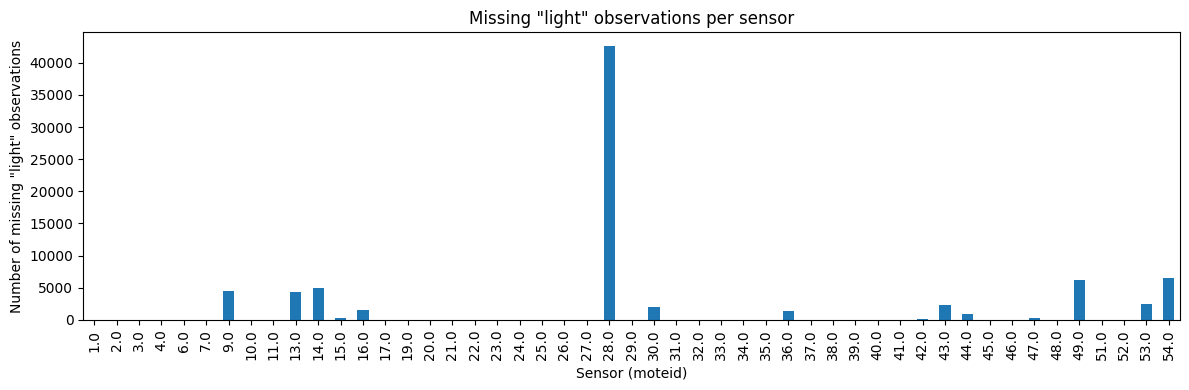

In [28]:
import matplotlib.pyplot as plt

missing_counts = df.groupby('moteid')['light'].apply(lambda x: x.isna().sum()).sort_index()

plt.figure(figsize=(12,4))
missing_counts.plot(kind='bar')
plt.xlabel('Sensor (moteid)')
plt.ylabel('Number of missing "light" observations')
plt.title('Missing "light" observations per sensor')
plt.tight_layout()
plt.show()

Sensor 28 has too many observations where the feature light is missing. I discard it as well.

In [29]:
df = df[df['moteid'] != 28]

df.isna().sum() / len(df)

epoch            0.000000
moteid           0.000000
temperature      0.000083
humidity         0.000082
light            0.018512
voltage          0.000000
time_sin         0.000000
time_cos         0.000000
day_sin          0.000000
day_cos          0.000000
day_month_sin    0.000000
day_month_cos    0.000000
day_year_sin     0.000000
day_year_cos     0.000000
dtype: float64

Remaining missing data is little compared to the size of the dataset. I drop the rows with missing data. Then, I observed that there are epochs with more than one observation per sensors. This happens because epochs is in the end a (given by the dataset) discretization of time. Therefore, in order to treat this as a time series, I aggregated (averaged) observed features per epoch.

In [30]:
df = df.dropna().reset_index(drop=True)

Finally I reindexed epochs and sensors ids.

In [31]:
#rename moteid
moteid_mapping = {old_id: new_id for new_id, old_id in enumerate(sorted(df['moteid'].unique()))}
df['moteid'] = df['moteid'].map(moteid_mapping)

first_epoch = df['epoch'].min()
df['epoch'] = df['epoch'] - first_epoch

assert df['epoch'].max() == df['epoch'].nunique()-1 #all epochs are present
print(len(df['epoch'].unique()))

65536


In [32]:
df.describe()

,epoch,moteid,temperature,humidity,light,voltage,time_sin,time_cos,day_sin,day_cos,day_month_sin,day_month_cos,day_year_sin,day_year_cos
count,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06,2.018262e+06
mean,3.287344e+04,2.379872e+01,3.619240e+01,3.479170e+01,4.064233e+02,2.504009e+00,-6.363534e-03,8.593441e-03,-9.072881e-02,5.578679e-02,2.122081e-01,-4.865913e-02,9.250925e-01,3.569005e-01
std,1.845445e+04,1.360880e+01,3.443827e+01,1.469368e+01,5.369504e+02,1.664324e-01,7.096220e-01,7.045018e-01,7.204686e-01,6.852602e-01,6.438395e-01,7.335333e-01,4.503089e-02,1.216479e-01
min,0.000000e+00,0.000000e+00,-3.840000e+01,-1.854520e+03,3.077160e-15,9.100830e-03,-1.000000e+00,-1.000000e+00,-9.749279e-01,-9.009689e-01,-9.987165e-01,-9.948693e-01,8.406184e-01,2.151610e-02
25%,1.733700e+04,1.300000e+01,2.043920e+01,3.279070e+01,3.956000e+01,2.414310e+00,-7.164034e-01,-6.913029e-01,-7.818315e-01,-2.225209e-01,-4.853020e-01,-7.587581e-01,8.919813e-01,2.595118e-01
50%,3.295300e+04,2.400000e+01,2.235020e+01,3.948420e+01,1.582400e+02,2.538120e+00,-1.258058e-02,1.359860e-02,0.000000e+00,-2.225209e-01,3.943559e-01,-5.064917e-02,9.338372e-01,3.576982e-01
75%,4.788300e+04,3.600000e+01,2.592720e+01,4.348570e+01,5.667200e+02,2.627960e+00,7.073638e-01,7.130465e-01,7.818315e-01,6.234898e-01,7.907757e-01,6.889669e-01,9.657399e-01,4.520722e-01
max,6.553500e+04,4.700000e+01,3.855680e+02,1.375120e+02,1.847360e+03,3.159150e+00,1.000000e+00,1.000000e+00,9.749279e-01,1.000000e+00,9.987165e-01,1.000000e+00,9.997685e-01,5.416278e-01


I could quickly see that the data contains errors: for example, the maximum temperature is 385 degrees Celsius. To fix this errors that would cause my model to learn from them and thus make it predict garbage, I decided to set a range of physically reasonable values for all features, and drop rows with observed values outside that range. I defined the following intervals:
- Voltage: [2, 3]. This comes from the dataset definition.
- Temperature: [8, 38]. Since it is an office environemnt, temperatures outside this range are impossible.
- Humidity: [0, 100]. The only valid theoretical range.
- Light: [0, 2000]. 0 is darkness. 2000 is very bright direct light. The sensors often glitch to extremely high negative or positive integers.

In [33]:
from stgae.data.preproccesing import filter_data_errors

df = filter_data_errors(df)

Dropped 307449 rows (15.2%) due to physical constraints.


Now let's visualize the data

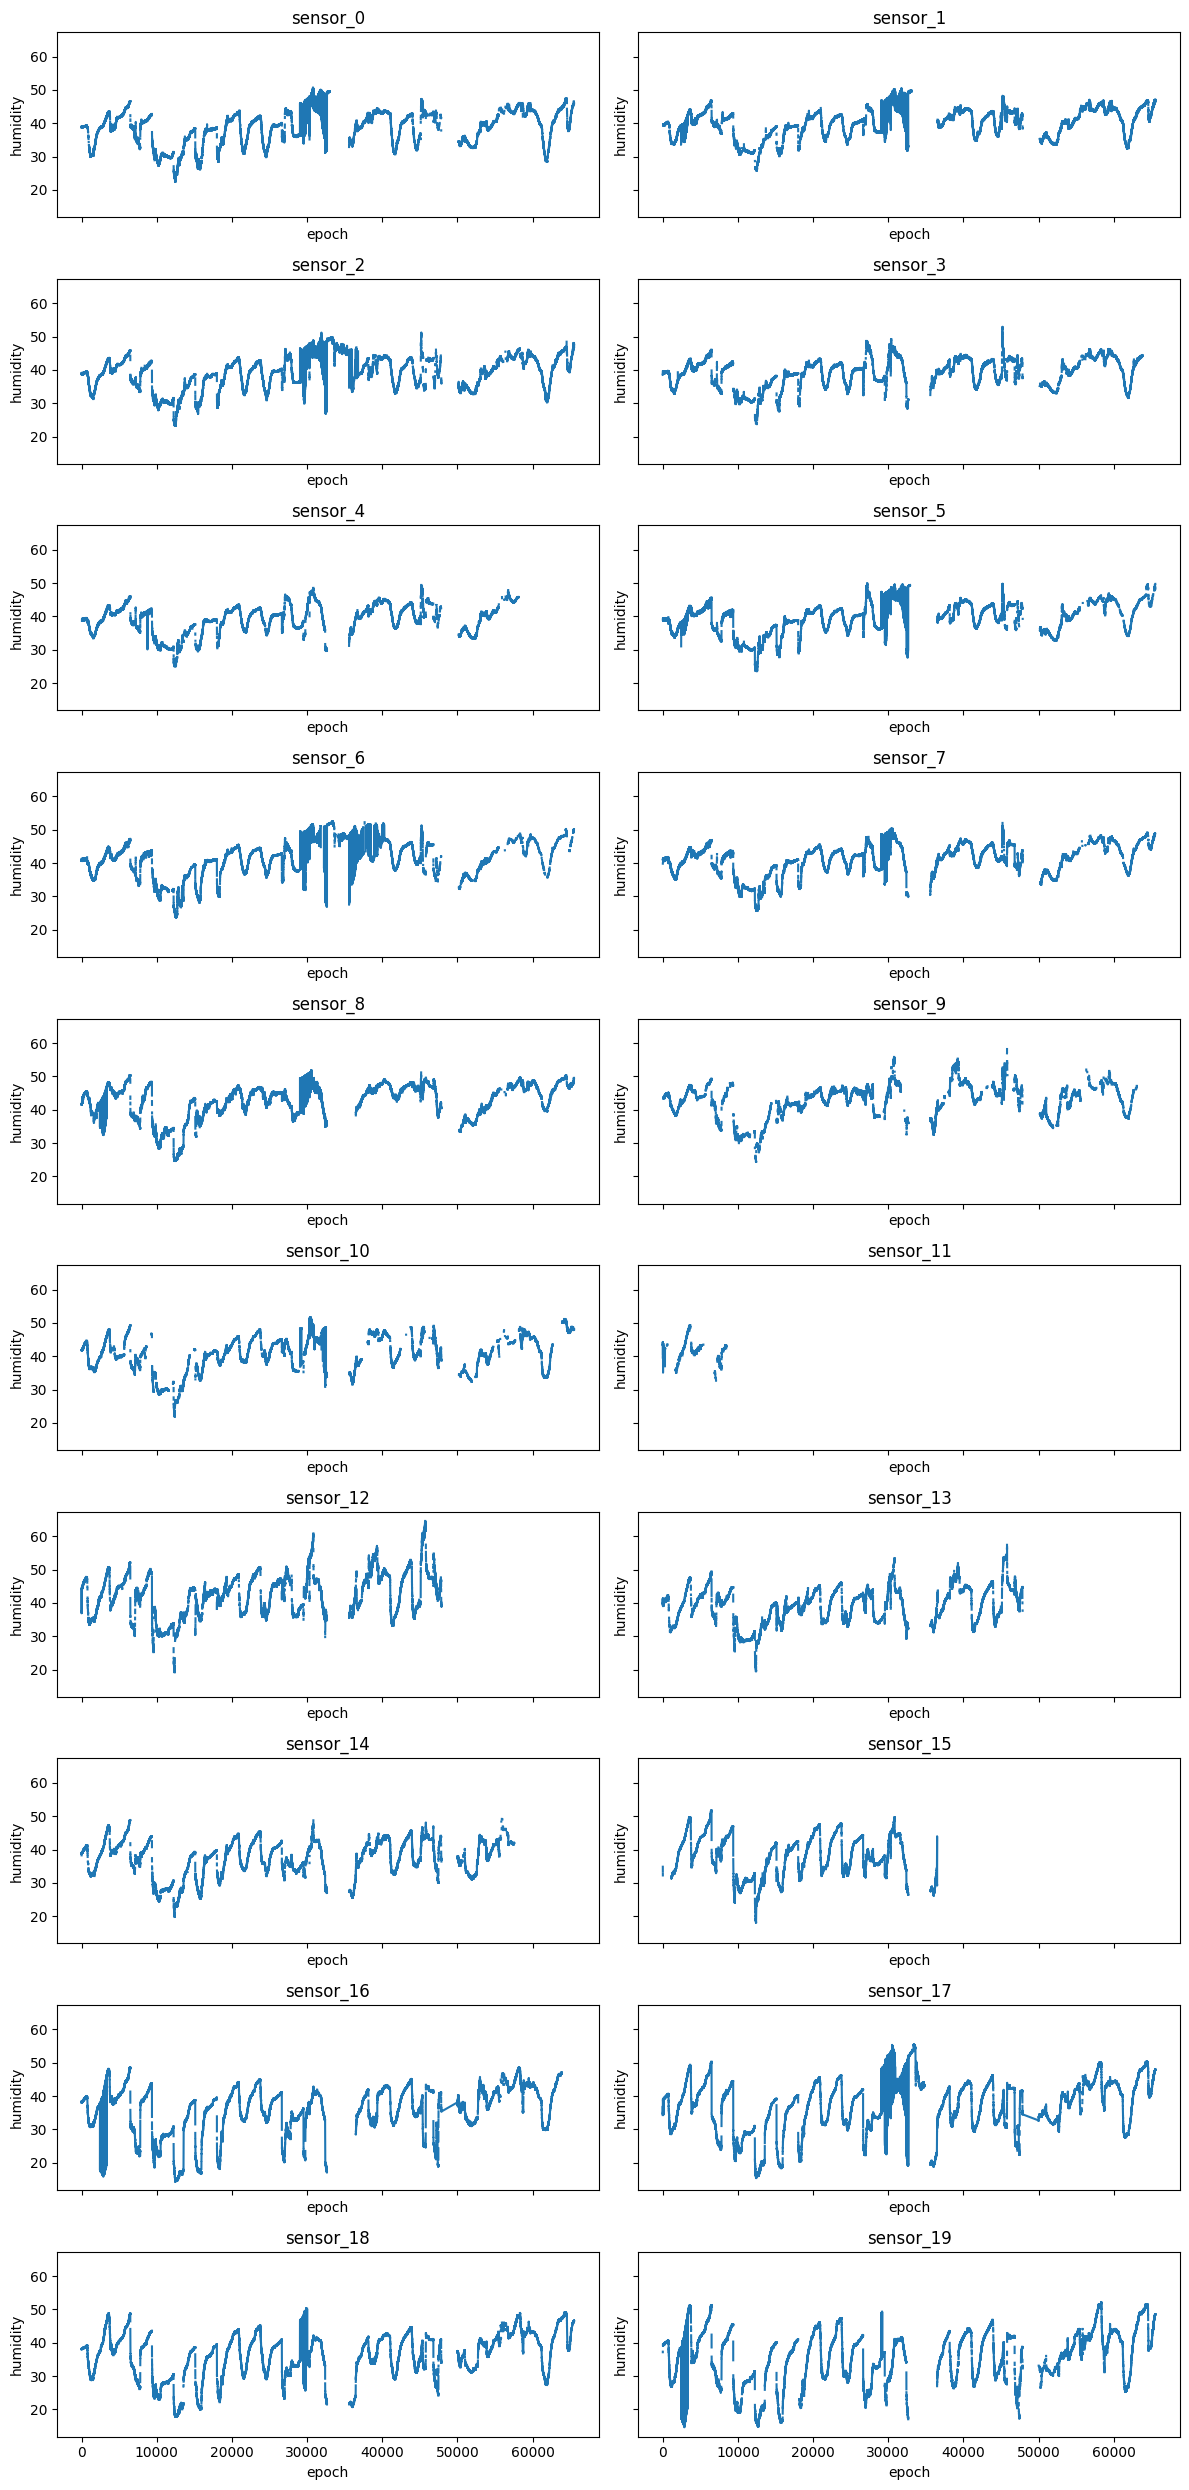

In [34]:
# plot humidity vs epoch for first 10 sensors (one subplot per sensor)
sensors = sorted(df['moteid'].unique())[:20]
temp_pivot = df.pivot(index='epoch', columns='moteid', values='humidity').sort_index()

n = len(sensors)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, rows*2.5), sharex=True, sharey=True)
# make sure axes is iterable even when rows*cols == 1
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for i, s in enumerate(sensors):
    axes[i].plot(temp_pivot.index, temp_pivot[s])
    axes[i].set_title(f'sensor_{int(s)}')
    axes[i].set_xlabel('epoch')
    axes[i].set_ylabel('humidity')

# remove any extra empty subplots
for j in range(len(sensors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Let's build the graph.
I decided to use a graph using knn (with k=5), and the edges weighted according to the inverse of the distance. 

Building adjacency matrix

In [35]:
from stgae.data.preproccesing import calculate_distances, calculate_adjacency_matrix

coordinates = pd.read_csv(paths['data_root'] / 'sensor_coordinates.txt', sep=' ')

dist_matrix = calculate_distances(coordinates) #numpy array

k=3 #for k-nearest neighbors adj matrix
exclude_sensors = [28, 5, 18, 50, 8, 12]

A = calculate_adjacency_matrix(dist_matrix, k=k, exclude=exclude_sensors) #assumes renaming of moteid, according to excluded sensors

assert A.shape[0] == len(df['moteid'].unique())

Now, I built the tensors to then create the Dataset.
I created X and M, of shapes
X: shape (T, N, F)
M: shape (T, N, 1)
where
X[t, n] = features of sensor n at epoch t
M[t, n] = 1 if sensor exists at epoch t, else 0

I am only intereseted in predicting original features (temperature, humidity, voltage, light) and not time related features, but I definitely want to use the time data to improve the model reconstruction capability. 

In [36]:
from stgae.data.preproccesing import build_tensors

#shapes:
#X: (time_steps, num_sensors, num_features), M: (time_steps, num_sensors), T_enc: (time_steps, num_time_features)

X, M, T_enc = build_tensors(df, epochs=df['epoch'].unique(), sensors=df['moteid'].unique(), feature_cols=['temperature', 'humidity', 'light', 'voltage'], time_cols=['time_sin', 'time_cos', 'day_sin', 'day_cos', 'day_month_sin', 'day_month_cos', 'day_year_sin', 'day_year_cos'])

Now lets build the dataset.  <br>
For a center time t, and a window size W: <br>
past window: [t-W, ..., t] <br>
future window: [t, ..., t+W] <br>

Masking: masking sensor level per window, that is, for each timestep, choose a subset of known sensors at that the center timestep and mask them in that timestep

In [37]:
from stgae.data.dataset import STBGNNDataset
from stgae.data.preproccesing import StandardScaler

train_split = 0.75
val_split = 0.1
T = X.shape[0]
train_size = int(T * train_split)
val_size = int(T * val_split)

#divide into train and val, keeping temporal order, to avoid leakage and learn temporal dependencies
X_train = X[:train_size]
X_val = X[train_size:train_size + val_size]
M_train = M[:train_size]
M_val = M[train_size:train_size + val_size]
T_enc_train = T_enc[:train_size] 
T_enc_val = T_enc[train_size:train_size+val_size]

#test dataset will be held out only for final evaluation, not for model selection
X_test = X[train_size + val_size:]
M_test = M[train_size + val_size:]
T_enc_test = T_enc[train_size + val_size :]

#i fit the scalar on the training data only to prevent leakeage
scaler = StandardScaler()
scaler.fit(X_train)

train_norm = scaler.transform(X_train)
val_norm = scaler.transform(X_val)
test_norm = scaler.transform(X_test)

train_dataset = STBGNNDataset(train_norm, M_train, T_enc, window_size=4, mask_ratio=0.5, split="train")
val_dataset = STBGNNDataset(val_norm, M_val, T_enc_val, window_size=4, mask_ratio=0.5, split="test")
test_dataset = STBGNNDataset(test_norm, M_test, T_enc_test, window_size=4, mask_ratio=0.5, split="test")

for k in train_dataset[0].keys():
    print(f'{k}: {train_dataset[0][k].shape}')

print('train dataset length:', len(train_dataset))
print('val dataset length:', len(val_dataset))
print('test dataset length:', len(test_dataset))

x_past_masked: torch.Size([5, 48, 4])
x_future_masked: torch.Size([5, 48, 4])
time_past: torch.Size([5, 8])
time_future: torch.Size([5, 8])
target: torch.Size([48, 4])
time_target: torch.Size([8])
loss_mask: torch.Size([48])
train dataset length: 47563
val dataset length: 6335
test dataset length: 9508


Note that masking in the training dataset is stochastic, while masking in the test dataset is deterministic. This is implemented using a local_rng for the test dataset (see code)

Training the model

In [38]:
import torch
from torch.utils.data import DataLoader
from stgae.model.bistgcn_opt import BiSTGCN
from stgae.model.train import train_step
from stgae.config.load_config import load_config
from stgae.model.evaluate import evaluate
from stgae.utils.utils import get_device

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-3
HIDDEN_DIM = 32
DEVICE = get_device()
SAVE_DIR = load_config()["paths"]["checkpoints"] #dir to store models

os.makedirs(SAVE_DIR, exist_ok=True)

# dataloader
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #this does not shuffle timesteps inside samples, but samples inside the batches and improves SGD 
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = BiSTGCN(in_features=train_dataset.F, hidden_dim=HIDDEN_DIM, adj=A).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
best_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    for batch_idx, batch in enumerate(train_dataloader):
        loss = train_step(batch, model, optimizer, DEVICE)
        train_loss += loss

        if batch_idx % 200 == 0:
            print(f"   Batch {batch_idx+1}/{len(train_dataloader)} - Train Loss: {loss:.6f}")
    avg_train_loss = train_loss / len(train_dataloader)

    val_mse, val_mae, val_rmse = evaluate(val_dataloader, model, DEVICE)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"   Train Loss: {avg_train_loss:.6f}")
    print(f"   Val MSE:    {val_mse:.6f}")
    print(f"   Val MAE:    {val_mae:.6f}")
    print(f"   Val RMSE:   {val_rmse:.6f}")

    if val_mse < best_loss:
        best_loss = val_mse
        best_path = os.path.join(SAVE_DIR, "bistgcn_best.pth")
        torch.save(model.state_dict(), best_path)
        print(f"   -> New best model saved to {best_path}")

    # 2. Save Checkpoint (For Resuming)
    # We save this every epoch. It includes optimizer state.
    checkpoint_path = os.path.join(SAVE_DIR, "bistgcn_last.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train_loss,
        'loss': val_mse,
    }, checkpoint_path)

   Batch 1/1487 - Train Loss: 1.254137
   Batch 201/1487 - Train Loss: 0.020074
   Batch 401/1487 - Train Loss: 0.007872
   Batch 601/1487 - Train Loss: 0.010282
   Batch 801/1487 - Train Loss: 0.008815
   Batch 1001/1487 - Train Loss: 0.007783
   Batch 1201/1487 - Train Loss: 0.007444
   Batch 1401/1487 - Train Loss: 0.006698
Epoch [1/5]
   Train Loss: 0.020740
   Val MSE:    0.007052
   Val MAE:    0.055855
   Val RMSE:   0.078626
   -> New best model saved to /Users/teonabot/Desktop/unibo/aiind/project/STGAE-for-anomaly-detection/src/stgae/model/checkpoints/bistgcn_best.pth
   Batch 1/1487 - Train Loss: 0.004661
   Batch 201/1487 - Train Loss: 0.004611
   Batch 401/1487 - Train Loss: 0.005612
   Batch 601/1487 - Train Loss: 0.003487
   Batch 801/1487 - Train Loss: 0.005717
   Batch 1001/1487 - Train Loss: 0.007074
   Batch 1201/1487 - Train Loss: 0.005910
   Batch 1401/1487 - Train Loss: 0.004653
Epoch [2/5]
   Train Loss: 0.005018
   Val MSE:    0.004429
   Val MAE:    0.037765
   

Evaluating the model.
Now I evaluated the trained model in the test dataset.

In [39]:
import torch
#load model
BATCH_SIZE = 32
CHECKPOINTS = load_config()["paths"]["checkpoints"]
HIDDEN_DIM = 32
DEVICE = get_device()


model_path = os.path.join(CHECKPOINTS, "bistgcn_best.pth")
model = BiSTGCN(in_features=train_dataset.F, hidden_dim=HIDDEN_DIM, adj=A).to(DEVICE)
checkpoint = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.eval()

test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

eval_mse, eval_mae, eval_rmse = evaluate(val_dataloader, model, DEVICE)

In [40]:
print(eval_mse, eval_mae, eval_rmse)

0.0029633766702538583 0.030223542626834278 0.048997175738667


Since the features are normalized we can interpret this results: looking at the MAE, we can esentially say that the model is missing the actual values by around 3%.